# Chapter 24: Holonomy

## Source Span And Goal

This notebook covers printed pages 245-251, PDF pages 274-280, of *Visual Differential Geometry and Forms*. The source pages were extracted and read for orientation only. The prose, code, diagrams, and checks here are original teaching material and do not copy textbook prose, exercises, screenshots, page crops, or figure layouts.

**Chapter goal.** Holonomy turns curvature into a measurable returned angle. Parallel transport a tangent vector around a closed loop, compare the returned vector with the initial one in the same tangent plane, and the signed angular discrepancy records the curvature enclosed by the loop.

The computational route is:

| Chapter idea | Computational translation | Inspection target |
| --- | --- | --- |
| holonomy of a loop | initial and returned tangent vectors at one basepoint | the signed angle `R(L)` |
| spherical triangle | great-circle transport on the unit sphere | `R = area = angular excess` |
| geodesic triangle ledger | interior and exterior angle bookkeeping | `2*pi - sum(phi_i) = sum(theta_i) - pi` |
| hyperbolic triangle | upper-half-plane geodesics, using conformal angles | `R = -area` for curvature `-1` |
| additivity | subdivide a region and cancel internal transports | only the outer boundary remains |
| curvature from small loops | sample `R(L)/area(L)` as loops shrink | the ratio tends to Gaussian curvature |

Library routing follows the course catalog: Matplotlib for durable annotated diagrams and ledgers, Plotly for the rotatable 3D sphere, NumPy for transport and geometric measurements, and SymPy for the exact angle identity.


## How To Read The Visuals

Holonomy is easy to misread because the moving vector is never being compared with vectors at other points of the surface. The comparison only happens after the vector returns to its starting tangent plane. While the vector is away from the basepoint, it is constrained by the transport rule: along a geodesic it keeps the same angle with the geodesic direction, and along a general curve it is carried by the surface connection rather than by a drawing convention in the page. The diagrams therefore use two kinds of arrows. Path arrows show the order in which the loop is traversed. Tangent arrows show the transported probe. Only the start and finish tangent arrows at the same basepoint form the holonomy angle.

The spherical and hyperbolic examples should be read as sign tests. On the unit sphere, a positively oriented geodesic triangle has positive enclosed curvature. The returned vector rotates in the same orientation as the boundary, and the angle equals the spherical area. In the upper-half-plane model, geodesics are vertical lines or semicircles orthogonal to the boundary. The model is conformal, so the drawn Euclidean angles are the hyperbolic angles, but Euclidean lengths and Euclidean areas are not the hyperbolic measurements. The hyperbolic triangle has angle sum less than `pi`; its angular excess is negative, and that negative number is the holonomy for curvature `-1`.

The additivity visuals are proof scaffolds rather than new examples. If a loop is subdivided, the inserted internal curve appears twice with opposite orientations. Parallel transport along that curve and immediately back is inverse composition, so the frame contribution is the identity. This is why the sum of small holonomies equals the holonomy of the outer boundary. The tessellation image shows the global bookkeeping, while the frame-cancellation image isolates the local reason that the bookkeeping works.

The infinitesimal plot connects the chapter to curvature itself. The ratio `R/area` is not meant to be a new definition for a large arbitrary loop on a variable-curvature surface. It is a limiting diagnostic: shrink the loop around a point, and the ratio approaches the Gaussian curvature at that point. The sampled sphere and hyperbolic rectangles are constant-curvature models, so their ratios are already locked at `+1` and `-1`; in a variable-curvature surface the same experiment would need smaller and smaller loops to isolate the local value.

## Common Misreadings This Notebook Tries To Prevent

First, holonomy is not the same thing as the visible turning of the path. A velocity vector tangent to the boundary can turn because the boundary turns. A transported tangent vector can return rotated even when it was kept as parallel as the surface permits. The angle ledger separates those two ideas by using exterior turns only as bookkeeping for geodesic sides.

Second, the basepoint is not a new datum of the holonomy angle for the simple loops used here. Starting at a different point on the same loop conjugates the transport description, but the returned rotation angle is the same. This is why the notebook can place the comparison at the most convenient vertex of the triangle.

Third, additivity is not a statement that rotations always commute in every possible setting. In this two-dimensional oriented tangent-plane setting, holonomy around these loops is recorded as a signed scalar angle. The cancellation argument is about composing transport maps along exactly the same internal curve in opposite directions. For higher-dimensional holonomy, the returned transformation can be a noncommuting matrix, and the order of loops becomes part of the data.

Finally, a conformal drawing of the hyperbolic plane preserves angles but not metric area. The hyperbolic triangle check uses conformal angles for the defect and the known constant-curvature relation `area = defect` for curvature `-1`. The rectangle samples use the half-plane area element, not the Euclidean area of the drawn rectangle.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch, Polygon
from PIL import Image
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the VDGF book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html

ARTIFACT_TOPIC = "chapter-24"
ARTIFACT_BASE = BOOK_ROOT / "artifacts"
FIGURE_SLUG = "figures"
CHECK_SLUG = "checks"
visual_registry = []
computed_checks = {}

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 170, "font.size": 10})


def rel_path(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def artifact_metrics(path: Path) -> dict:
    path = Path(path)
    metrics = {"file_size": path.stat().st_size, "suffix": path.suffix.lower()}
    if path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        with Image.open(path) as image:
            array = np.asarray(image.convert("RGB"), dtype=float)
        metrics.update({
            "width": int(array.shape[1]),
            "height": int(array.shape[0]),
            "pixel_std": float(array.std()),
            "pixel_mean": float(array.mean()),
            "nonblank": bool(array.std() > 1.0 and path.stat().st_size > 1000),
        })
    else:
        metrics["nonblank"] = bool(path.stat().st_size > 1000)
    return metrics


def register(path: Path, concept: str, kind: str, library: str, inspection: str, validation: dict | None = None) -> None:
    visual_registry.append({
        "filename": path.name,
        "relative_path": rel_path(path),
        "concept": concept,
        "kind": kind,
        "library": library,
        "inspection_target": inspection,
        "validation": validation or {},
        "metrics": artifact_metrics(path),
    })


def save_fig(fig, filename: str) -> Path:
    path = save_matplotlib(fig, ARTIFACT_TOPIC, FIGURE_SLUG, filename, root=ARTIFACT_BASE)
    plt.close(fig)
    return path


def unit(v):
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("zero vector")
    return v / norm


def rotate2(v, angle):
    c, s = math.cos(angle), math.sin(angle)
    return np.array([[c, -s], [s, c]]) @ np.asarray(v, dtype=float)


def rotation_matrix(axis, angle):
    axis = unit(axis)
    x, y, z = axis
    K = np.array([[0, -z, y], [z, 0, -x], [-y, x, 0]])
    I = np.eye(3)
    return I + math.sin(angle) * K + (1 - math.cos(angle)) * (K @ K)


def sphere_transport(p, q, tangent):
    p, q = unit(p), unit(q)
    axis = np.cross(p, q)
    axis_norm = np.linalg.norm(axis)
    if axis_norm < 1e-12:
        return np.asarray(tangent, dtype=float)
    angle = math.atan2(axis_norm, float(np.dot(p, q)))
    return rotation_matrix(axis, angle) @ np.asarray(tangent, dtype=float)


def sphere_loop_transport(vertices, tangent):
    transported = np.asarray(tangent, dtype=float)
    for p, q in zip(vertices, vertices[1:] + vertices[:1]):
        transported = sphere_transport(p, q, transported)
    return transported


def tangent_toward_on_sphere(p, q):
    p, q = unit(p), unit(q)
    return unit(q - np.dot(q, p) * p)


def signed_tangent_angle(normal, start, finish):
    normal, start, finish = unit(normal), unit(start), unit(finish)
    return math.atan2(float(np.dot(np.cross(start, finish), normal)), float(np.dot(start, finish)))


def great_circle_points(a, b, n=90):
    a, b = unit(a), unit(b)
    axis = np.cross(a, b)
    axis_norm = np.linalg.norm(axis)
    if axis_norm < 1e-12:
        return np.repeat(a[None, :], n, axis=0)
    angle = math.atan2(axis_norm, float(np.dot(a, b)))
    return np.array([rotation_matrix(axis, t * angle) @ a for t in np.linspace(0, 1, n)])


def spherical_triangle_area(a, b, c):
    a, b, c = unit(a), unit(b), unit(c)
    numerator = float(np.linalg.det(np.vstack([a, b, c])))
    denominator = 1 + float(np.dot(a, b) + np.dot(b, c) + np.dot(c, a))
    return 2 * math.atan2(numerator, denominator)


def hp_circle(p, q):
    x1, y1 = p
    x2, y2 = q
    if abs(x2 - x1) < 1e-12:
        return None
    center = ((x2 * x2 + y2 * y2) - (x1 * x1 + y1 * y1)) / (2 * (x2 - x1))
    radius = math.hypot(x1 - center, y1)
    return center, radius


def hp_geodesic_points(p, q, n=100):
    circle = hp_circle(p, q)
    if circle is None:
        return np.column_stack([np.full(n, p[0]), np.linspace(p[1], q[1], n)])
    center, radius = circle
    th1 = math.atan2(p[1], p[0] - center)
    th2 = math.atan2(q[1], q[0] - center)
    th = np.linspace(th1, th2, n)
    return np.column_stack([center + radius * np.cos(th), radius * np.sin(th)])


def hp_tangent_to(p, q):
    circle = hp_circle(p, q)
    if circle is None:
        return np.array([0.0, math.copysign(1.0, q[1] - p[1])])
    center, _ = circle
    th1 = math.atan2(p[1], p[0] - center)
    th2 = math.atan2(q[1], q[0] - center)
    direction = 1.0 if th2 > th1 else -1.0
    return unit(direction * np.array([-math.sin(th1), math.cos(th1)]))


def hp_triangle_angles(vertices):
    angles = []
    for i, vertex in enumerate(vertices):
        prev_vec = hp_tangent_to(vertex, vertices[(i - 1) % 3])
        next_vec = hp_tangent_to(vertex, vertices[(i + 1) % 3])
        angles.append(math.acos(np.clip(float(np.dot(prev_vec, next_vec)), -1, 1)))
    return angles


print(f"Book root: {BOOK_ROOT.name}")
print(f"Artifacts: {rel_path(ARTIFACT_BASE / ARTIFACT_TOPIC)}")

Book root: Visual-Differential-Geometry-and-Forms
Artifacts: artifacts/chapter-24


In [2]:
source_span = {
    "label": "Chapter 24",
    "title": "Holonomy",
    "printed_pages": "245-251",
    "pdf_pages": "274-280",
    "source_pdf": "Visual Differential Geometry and Forms.pdf",
    "source_words_read_by_pdftotext": 2565,
    "focus": "Curvature can be detected by the angle picked up when tangent vectors are parallel transported around loops.",
    "topics": [
        "Holonomy on the sphere",
        "Geodesic triangles and angular excess",
        "Holonomy of general geodesic triangles",
        "Additivity of holonomy over subdivided regions",
        "Hyperbolic-plane examples",
        "Curvature as infinitesimal rotational failure",
    ],
    "copyright_note": "Source pages were read for orientation only; no source prose, screenshots, crops, or figure layouts are reproduced.",
}

storyboard = {
    "chapter_label": "Chapter 24",
    "chapter_number": 24,
    "title": "Holonomy",
    "chapter_goal": "Measure curvature by the returned angle after parallel transport around a loop.",
    "source_span_read": {
        "printed_span": "245-251",
        "pdf_span": "274-280",
        "source_pdf": "Visual Differential Geometry and Forms.pdf",
        "pdftotext_word_count": 2565,
        "source_map_note": "VDGF source map uses pdf_page = printed_page + 29.",
    },
    "concept_inventory": [
        "holonomy as a basepoint-independent net rotation of the transported tangent plane",
        "sphere triangle holonomy equals angular excess and enclosed area on the unit sphere",
        "triangle exterior-angle ledger converts transport turns into angular excess",
        "subdivision additivity comes from cancellation along shared internal edges",
        "hyperbolic half-plane geodesics give negative holonomy equal to angular defect",
        "small-loop holonomy per area samples Gaussian curvature",
    ],
    "library_routing_table": [
        {"concept": "loop meter", "representation": "oriented loop and returned vector gauge", "library": "Matplotlib", "why": "annotated 2D angle and area ledger"},
        {"concept": "spherical transport", "representation": "great-circle loop with transported frame", "library": "Plotly, Matplotlib, NumPy", "why": "3D inspection plus durable PNG"},
        {"concept": "triangle identity", "representation": "symbolic ledger", "library": "SymPy and Matplotlib", "why": "exact identity plus readable bookkeeping"},
        {"concept": "hyperbolic triangle", "representation": "upper-half-plane geodesics", "library": "Matplotlib and NumPy", "why": "conformal angles are directly inspectable"},
        {"concept": "additivity and frame cancellation", "representation": "tessellation and inverse-transport diagram", "library": "Matplotlib and NumPy", "why": "the proof is visual and algebraic"},
        {"concept": "infinitesimal curvature", "representation": "area-versus-holonomy ratio plots", "library": "Matplotlib and NumPy", "why": "ratio plot exposes curvature sign"},
    ],
    "visual_sequence": [
        {"filename": "holonomy-loop-meter.png", "concept": "Holonomy loop meter", "library": "Matplotlib", "inspection_target": "compare start and returned vectors at one basepoint", "validation": "K times area gives the meter estimate"},
        {"filename": "sphere-triangle-holonomy.png", "concept": "Spherical triangle holonomy", "library": "Matplotlib 3D and NumPy", "inspection_target": "returned vector rotates by spherical excess", "validation": "transport angle equals pi/2"},
        {"filename": "spherical-holonomy-loop.html", "concept": "Interactive spherical transport loop", "library": "Plotly", "inspection_target": "rotate the sphere to inspect the loop and tangent comparison", "validation": "same sphere transport check"},
        {"filename": "geodesic-triangle-angle-ledger.png", "concept": "Geodesic triangle angle ledger", "library": "Matplotlib and SymPy", "inspection_target": "exterior-turn deficit equals angular excess", "validation": "SymPy simplifies R - E to zero"},
        {"filename": "hyperbolic-triangle-holonomy.png", "concept": "Hyperbolic triangle holonomy", "library": "Matplotlib and NumPy", "inspection_target": "angle sum below pi gives negative returned angle", "validation": "holonomy equals negative defect area"},
        {"filename": "holonomy-additivity-tessellation.png", "concept": "Holonomy additivity over tessellated regions", "library": "Matplotlib and NumPy", "inspection_target": "internal edges cancel", "validation": "solid-angle additivity"},
        {"filename": "transport-frame-cancellation.png", "concept": "Transport frame cancellation", "library": "Matplotlib", "inspection_target": "forward then reverse transport is identity", "validation": "T_reverse*T_forward = I"},
        {"filename": "infinitesimal-curvature-rotation-check.png", "concept": "Infinitesimal curvature-rotation checks", "library": "Matplotlib and NumPy", "inspection_target": "R/area tends to +1 on sphere and -1 in hyperbolic plane", "validation": "ratio residuals below tolerance"},
    ],
    "artifact_plan": {"figures": "artifacts/chapter-24/figures/", "checks": "artifacts/chapter-24/checks/"},
    "computational_checks": [
        "sphere octant transport angle equals spherical excess pi/2",
        "general geodesic triangle identity R = E is verified symbolically",
        "hyperbolic triangle holonomy is negative and equals -area for K=-1",
        "spherical solid-angle additivity has near-zero residual",
        "hyperbolic rectangle holonomy divided by area is -1 across shrinking samples",
        "all concept-named artifacts exist and are nonblank",
    ],
    "proof_visualization_strategy": "Use an angle ledger for R=E and cancellation diagrams for additivity.",
}

source_path = save_json(source_span, ARTIFACT_TOPIC, CHECK_SLUG, "source-span.json", root=ARTIFACT_BASE)
storyboard_path = save_json(storyboard, ARTIFACT_TOPIC, CHECK_SLUG, "visual-storyboard.json", root=ARTIFACT_BASE)
print(rel_path(source_path))
print(rel_path(storyboard_path))
print(f"storyboard visuals: {len(storyboard['visual_sequence'])}")

artifacts/chapter-24/checks/source-span.json
artifacts/chapter-24/checks/visual-storyboard.json
storyboard visuals: 8


## Holonomy As A Loop Meter

Holonomy is a returned-angle measurement. The loop has an orientation and an enclosed region; the initial and returned vectors live in the same tangent plane at the basepoint; the meter reads the signed angle `R(L)`. When curvature is nearly constant on the region, the first estimate is `R(L) ~= K * area(L)`. The following diagram makes the measurement data explicit before we move to exact sphere and hyperbolic checks.

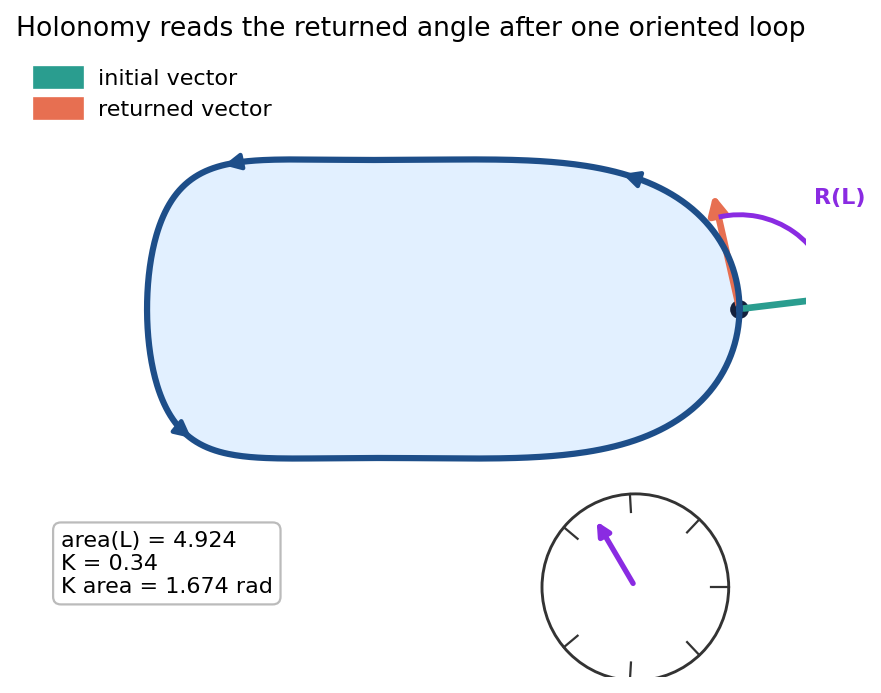

In [3]:
theta = np.linspace(0, 2 * math.pi, 500)
loop_x = 1.65 * np.cos(theta) + 0.18 * np.cos(2 * theta)
loop_y = 0.95 * np.sin(theta) + 0.12 * np.sin(3 * theta)
area = 0.5 * abs(np.dot(loop_x, np.roll(loop_y, -1)) - np.dot(loop_y, np.roll(loop_x, -1)))
K_model = 0.34
R_model = K_model * area
base = np.array([loop_x[0], loop_y[0]])
start = unit(np.array([1.0, 0.12]))
finish = rotate2(start, R_model)

fig, ax = plt.subplots(figsize=(8.8, 5.1))
ax.fill(loop_x, loop_y, color="#d8ebff", alpha=0.72)
ax.plot(loop_x, loop_y, color="#1d4e89", linewidth=2.8)
for idx in [55, 170, 300]:
    ax.add_patch(FancyArrowPatch((loop_x[idx], loop_y[idx]), (loop_x[idx + 8], loop_y[idx + 8]), arrowstyle="-|>", mutation_scale=15, color="#1d4e89", linewidth=2))
ax.scatter([base[0]], [base[1]], s=55, color="#14213d")
ax.add_patch(FancyArrowPatch(base, base + 0.68 * start, arrowstyle="-|>", mutation_scale=17, color="#2a9d8f", linewidth=3, label="initial vector"))
ax.add_patch(FancyArrowPatch(base, base + 0.68 * finish, arrowstyle="-|>", mutation_scale=17, color="#e76f51", linewidth=3, label="returned vector"))
a0 = math.degrees(math.atan2(start[1], start[0]))
a1 = math.degrees(math.atan2(finish[1], finish[0]))
ax.add_patch(Arc(base, 1.05, 1.05, theta1=a0, theta2=a1, color="#8a2be2", linewidth=2.2))
mid = math.radians((a0 + a1) / 2)
ax.text(base[0] + 0.72 * math.cos(mid), base[1] + 0.72 * math.sin(mid), "R(L)", color="#8a2be2", weight="bold")
meter = np.array([1.25, -1.55])
ax.add_patch(Circle(meter, 0.52, fill=False, edgecolor="#333333", linewidth=1.3))
for frac in np.linspace(0, 1, 7):
    ang = math.radians(-140 + 280 * frac)
    ax.plot([meter[0] + 0.42 * math.cos(ang), meter[0] + 0.52 * math.cos(ang)], [meter[1] + 0.42 * math.sin(ang), meter[1] + 0.52 * math.sin(ang)], color="#333333", linewidth=1)
needle_ang = math.radians(-140 + 280 * min(R_model / 1.8, 1.0))
ax.add_patch(FancyArrowPatch(meter, meter + 0.45 * np.array([math.cos(needle_ang), math.sin(needle_ang)]), arrowstyle="-|>", mutation_scale=12, color="#8a2be2", linewidth=2.4))
ax.text(-1.95, -1.58, f"area(L) = {area:.3f}\nK = {K_model:.2f}\nK area = {R_model:.3f} rad", bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#bbbbbb"})
ax.set_title("Holonomy reads the returned angle after one oriented loop")
ax.set_aspect("equal")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.05, 1.45)
ax.axis("off")
ax.legend(loc="upper left", frameon=False)
path = save_fig(fig, "holonomy-loop-meter.png")
register(path, "Holonomy loop meter", "transport", "Matplotlib", "Compare the initial and returned vectors at the same basepoint.", {"curvature": K_model, "area": area, "holonomy": R_model})
computed_checks["loop_meter"] = {"area": area, "curvature": K_model, "holonomy": R_model}
display_artifact(path, width=760)

## Spherical Triangle: Positive Curvature Gives Positive Holonomy

On the unit sphere, parallel transport along a great-circle segment is computed by rotating three-dimensional space about the great-circle axis. For the octant triangle `north pole -> equator longitude 0 -> equator longitude pi/2 -> north pole`, every interior angle is `pi/2`, so the spherical excess is `pi/2`. The returned vector below is rotated by that same angle.

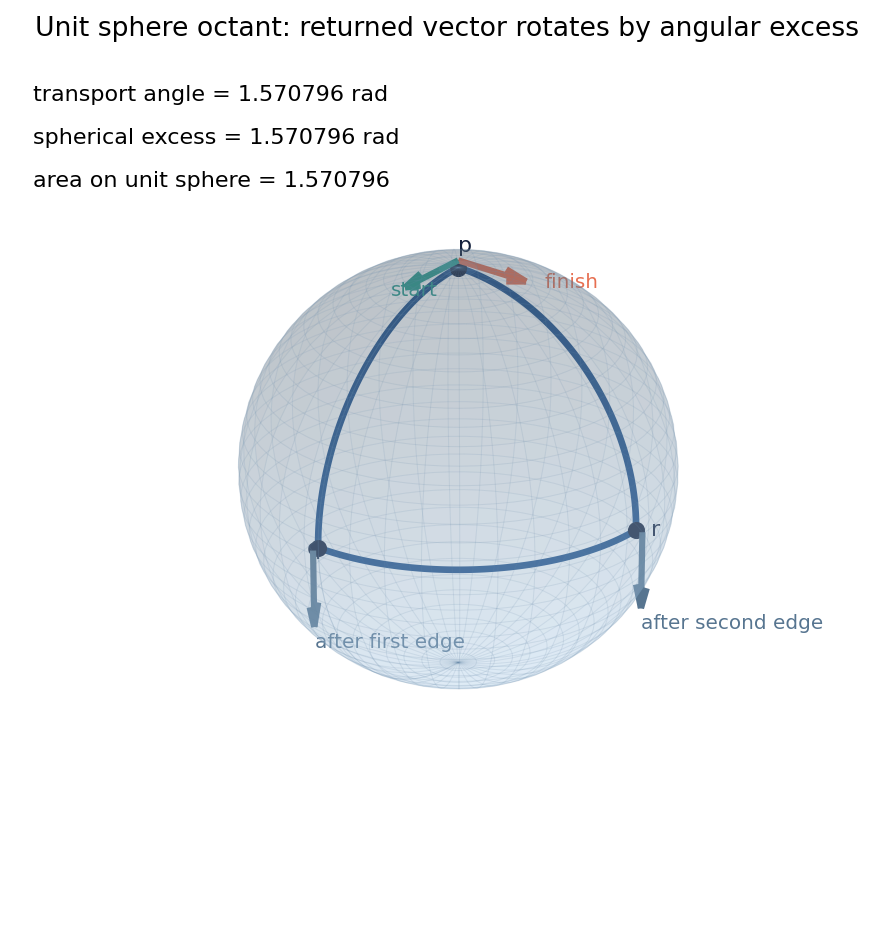

In [4]:
north = np.array([0.0, 0.0, 1.0])
equator_x = np.array([1.0, 0.0, 0.0])
equator_y = np.array([0.0, 1.0, 0.0])
v0 = tangent_toward_on_sphere(north, equator_x)
v_q = sphere_transport(north, equator_x, v0)
v_r = sphere_transport(equator_x, equator_y, v_q)
v_final = sphere_transport(equator_y, north, v_r)
sphere_angle = signed_tangent_angle(north, v0, v_final)
sphere_excess = math.pi / 2
sphere_area = spherical_triangle_area(north, equator_x, equator_y)

fig = plt.figure(figsize=(8.6, 7.0))
ax = fig.add_subplot(111, projection="3d")
phi = np.linspace(0, math.pi, 38)
lam = np.linspace(0, 2 * math.pi, 76)
xx = np.outer(np.sin(phi), np.cos(lam))
yy = np.outer(np.sin(phi), np.sin(lam))
zz = np.outer(np.cos(phi), np.ones_like(lam))
ax.plot_surface(xx, yy, zz, color="#bde0fe", edgecolor="none", alpha=0.22)
ax.plot_wireframe(xx, yy, zz, color="#6c8ead", alpha=0.16, linewidth=0.45)
for a, b in [(north, equator_x), (equator_x, equator_y), (equator_y, north)]:
    pts = great_circle_points(a, b, 100)
    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], color="#1d4e89", linewidth=3)
for label, point in [("p", north), ("q", equator_x), ("r", equator_y)]:
    ax.scatter([point[0]], [point[1]], [point[2]], s=45, color="#14213d")
    ax.text(*(point * 1.08), label, color="#14213d")
for base, vec, color, label in [(north, v0, "#2a9d8f", "start"), (equator_x, v_q, "#577590", "after first edge"), (equator_y, v_r, "#577590", "after second edge"), (north, v_final, "#e76f51", "finish")]:
    off = 0.035 * unit(base)
    ax.quiver(base[0] + off[0], base[1] + off[1], base[2] + off[2], vec[0], vec[1], vec[2], length=0.38, normalize=True, color=color, linewidth=2.8)
    ax.text(*(base + 0.48 * unit(vec) + off), label, color=color, fontsize=9)
ax.text2D(0.02, 0.94, f"transport angle = {sphere_angle:.6f} rad", transform=ax.transAxes)
ax.text2D(0.02, 0.89, f"spherical excess = {sphere_excess:.6f} rad", transform=ax.transAxes)
ax.text2D(0.02, 0.84, f"area on unit sphere = {sphere_area:.6f}", transform=ax.transAxes)
ax.set_title("Unit sphere octant: returned vector rotates by angular excess")
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=26, azim=38)
ax.set_axis_off()
path_png = save_fig(fig, "sphere-triangle-holonomy.png")
register(path_png, "Spherical triangle holonomy", "geometry", "Matplotlib 3D and NumPy", "The green start tangent and orange returned tangent at p differ by spherical excess.", {"transport_angle": sphere_angle, "excess": sphere_excess, "area": sphere_area})

traces = [go.Surface(x=xx, y=yy, z=zz, opacity=0.24, colorscale=[[0, "#bde0fe"], [1, "#bde0fe"]], showscale=False, name="unit sphere")]
for name, a, b in [("p to q", north, equator_x), ("q to r", equator_x, equator_y), ("r to p", equator_y, north)]:
    pts = great_circle_points(a, b, 120)
    traces.append(go.Scatter3d(x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], mode="lines", line={"color": "#1d4e89", "width": 6}, name=name))
for name, base, vec, color in [("start vector", north, v0, "#2a9d8f"), ("returned vector", north, v_final, "#e76f51"), ("transported at q", equator_x, v_q, "#577590"), ("transported at r", equator_y, v_r, "#577590")]:
    pts = np.vstack([base + 0.04 * unit(base), base + 0.04 * unit(base) + 0.42 * unit(vec)])
    traces.append(go.Scatter3d(x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], mode="lines", line={"color": color, "width": 8}, name=name))
fig3d = go.Figure(data=traces)
fig3d.update_layout(title="Spherical holonomy loop", scene={"aspectmode": "data", "xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False}}, margin={"l": 0, "r": 0, "t": 42, "b": 0})
path_html = save_plotly_html(fig3d, ARTIFACT_TOPIC, FIGURE_SLUG, "spherical-holonomy-loop.html", root=ARTIFACT_BASE, include_plotlyjs="cdn")
register(path_html, "Interactive spherical transport loop", "interactive-3d", "Plotly", "Rotate the sphere to inspect the loop and start/finish tangents.", {"transport_angle": sphere_angle, "excess": sphere_excess})

computed_checks["sphere_octant"] = {"transport_angle": sphere_angle, "spherical_excess": sphere_excess, "area": sphere_area, "absolute_error": abs(sphere_angle - sphere_excess)}
assert abs(sphere_angle - sphere_excess) < 1e-12
assert abs(sphere_area - sphere_excess) < 1e-12
display_artifact(path_png, width=760)
display_artifact(path_html, width="100%", height=430)

## Triangle Ledger And Hyperbolic Sign

For a geodesic triangle, start with a vector tangent to the first edge. Parallel transport keeps a constant angle with each geodesic edge, so the returned rotation is the exterior-turn deficit

`R(Delta) = 2*pi - (phi_1 + phi_2 + phi_3)`.

Since `phi_i = pi - theta_i`, this is the angular excess `theta_1 + theta_2 + theta_3 - pi`. On the sphere this is positive. In the hyperbolic plane the angle sum is below `pi`, so holonomy is negative.

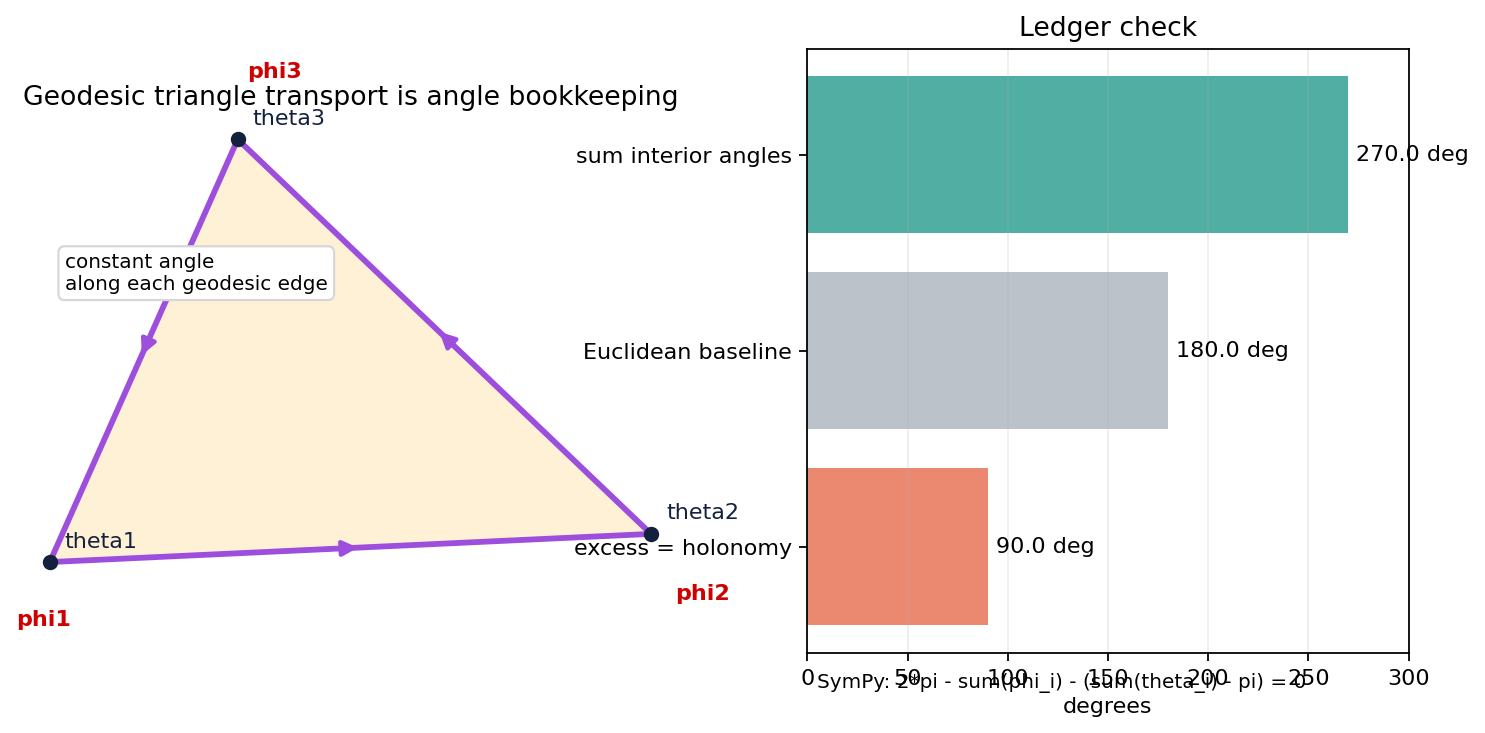

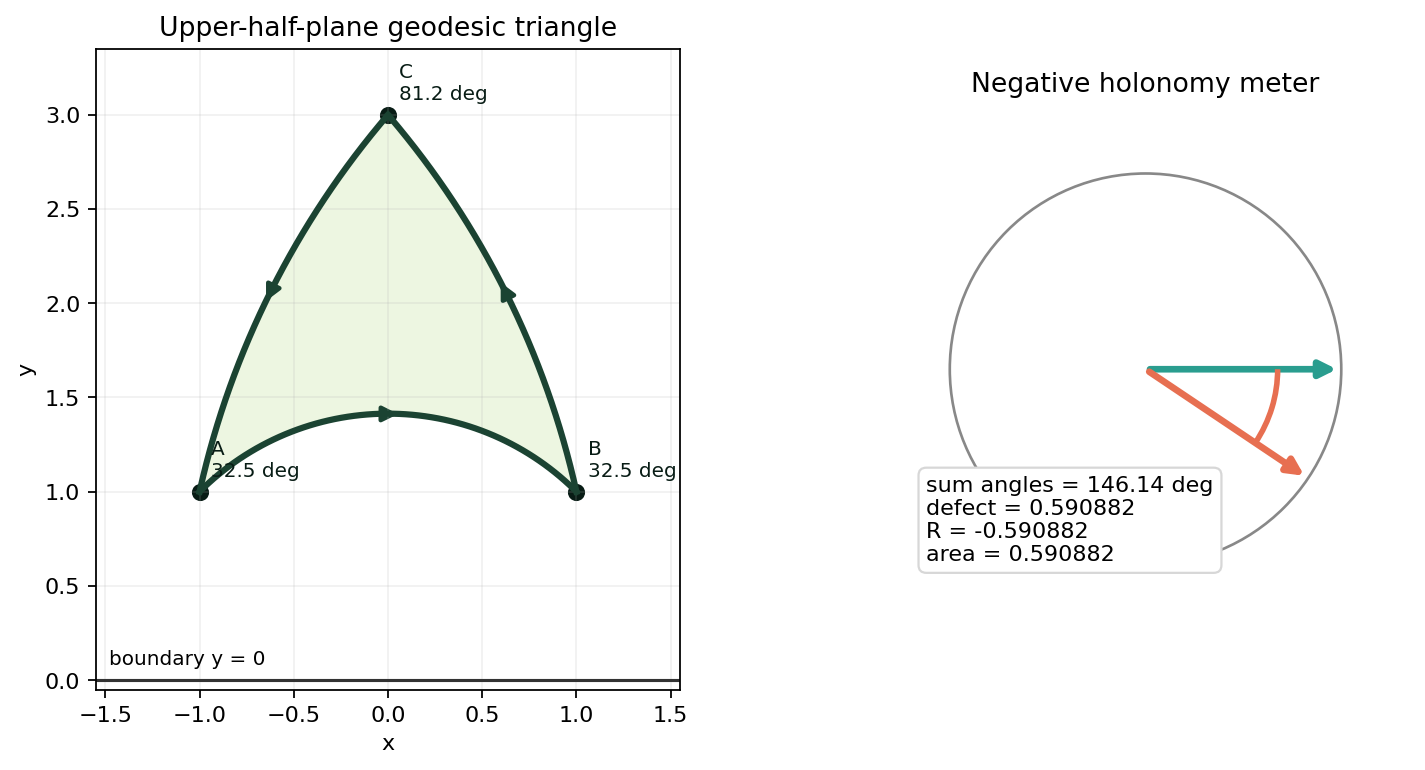

In [5]:
theta1, theta2, theta3 = sp.symbols("theta1 theta2 theta3")
phis = [sp.pi - t for t in (theta1, theta2, theta3)]
R_expr = 2 * sp.pi - sum(phis)
E_expr = theta1 + theta2 + theta3 - sp.pi
sympy_residual = sp.simplify(R_expr - E_expr)
assert sympy_residual == 0

sample_degrees = np.array([100.0, 95.0, 75.0])
sample_theta = np.deg2rad(sample_degrees)
sample_phi = math.pi - sample_theta
sample_R = 2 * math.pi - float(sample_phi.sum())
sample_E = float(sample_theta.sum() - math.pi)

fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.2, 4.9), gridspec_kw={"width_ratios": [1.1, 1.0]})
tri = np.array([[0.0, 0.0], [3.2, 0.15], [1.0, 2.25]])
ax.add_patch(Polygon(tri, closed=True, facecolor="#fff1d6", edgecolor="#9d4edd", linewidth=2.6))
for i, label in enumerate(["theta1", "theta2", "theta3"]):
    ax.scatter(tri[i, 0], tri[i, 1], color="#14213d", s=35)
    ax.text(tri[i, 0] + 0.08, tri[i, 1] + 0.08, label, color="#14213d")
for i in range(3):
    p0, p1 = tri[i], tri[(i + 1) % 3]
    ax.add_patch(FancyArrowPatch(0.62 * p0 + 0.38 * p1, 0.48 * p0 + 0.52 * p1, arrowstyle="-|>", mutation_scale=14, color="#9d4edd", linewidth=2))
for text, pos in zip(["phi1", "phi2", "phi3"], [[-0.18, -0.34], [3.33, -0.2], [1.05, 2.58]]):
    ax.text(pos[0], pos[1], text, color="#d00000", weight="bold")
ax.text(0.08, 1.45, "constant angle\nalong each geodesic edge", fontsize=9, bbox={"boxstyle": "round,pad=0.32", "facecolor": "white", "edgecolor": "#d7d7d7"})
ax.set_title("Geodesic triangle transport is angle bookkeeping")
ax.set_aspect("equal")
ax.axis("off")
bars = [("sum interior angles", float(sample_theta.sum()), "#2a9d8f"), ("Euclidean baseline", math.pi, "#adb5bd"), ("excess = holonomy", sample_E, "#e76f51")]
for y, (label, value, color) in zip(np.arange(3)[::-1], bars):
    bx.barh(y, math.degrees(value), color=color, alpha=0.82)
    bx.text(math.degrees(value) + 4, y, f"{math.degrees(value):.1f} deg", va="center")
bx.set_yticks(np.arange(3)[::-1], [b[0] for b in bars])
bx.set_xlim(0, 300)
bx.set_xlabel("degrees")
bx.set_title("Ledger check")
bx.grid(axis="x", alpha=0.22)
bx.text(5, -0.72, "SymPy: 2*pi - sum(phi_i) - (sum(theta_i) - pi) = 0", fontsize=9)
path = save_fig(fig, "geodesic-triangle-angle-ledger.png")
register(path, "Geodesic triangle angle ledger", "proof", "Matplotlib and SymPy", "Read the same returned angle as exterior-turn deficit and angular excess.", {"sympy_residual": str(sympy_residual), "sample_holonomy": sample_R, "sample_excess": sample_E})
computed_checks["triangle_ledger"] = {"sympy_residual": str(sympy_residual), "sample_holonomy": sample_R, "sample_excess": sample_E, "absolute_error": abs(sample_R - sample_E)}
display_artifact(path, width=760)

A, B, C = (-1.0, 1.0), (1.0, 1.0), (0.0, 3.0)
h_vertices = [A, B, C]
h_angles = hp_triangle_angles(h_vertices)
h_angle_sum = float(sum(h_angles))
h_area = math.pi - h_angle_sum
h_holonomy = h_angle_sum - math.pi
edges = [hp_geodesic_points(A, B, 130), hp_geodesic_points(B, C, 130), hp_geodesic_points(C, A, 130)]
h_path = np.vstack(edges)
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.2, 5.2), gridspec_kw={"width_ratios": [1.25, 0.9]})
ax.fill(h_path[:, 0], h_path[:, 1], color="#e9f5db", alpha=0.82)
for edge in edges:
    ax.plot(edge[:, 0], edge[:, 1], color="#1b4332", linewidth=2.8)
    idx = len(edge) // 2
    ax.add_patch(FancyArrowPatch(edge[idx - 4], edge[idx + 4], arrowstyle="-|>", mutation_scale=14, color="#1b4332", linewidth=2))
for label, point, angle in zip(["A", "B", "C"], h_vertices, h_angles):
    ax.scatter([point[0]], [point[1]], s=45, color="#081c15")
    ax.text(point[0] + 0.06, point[1] + 0.08, f"{label}\n{math.degrees(angle):.1f} deg", color="#081c15", fontsize=9)
ax.axhline(0, color="#333333", linewidth=1.4)
ax.text(-1.48, 0.08, "boundary y = 0", fontsize=9)
ax.set_xlim(-1.55, 1.55)
ax.set_ylim(-0.05, 3.35)
ax.set_aspect("equal")
ax.set_title("Upper-half-plane geodesic triangle")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.18)
center = np.array([0.0, 0.0])
start = np.array([1.0, 0.0])
finish = rotate2(start, h_holonomy)
bx.add_patch(Circle(center, 1.0, fill=False, edgecolor="#888888", linewidth=1.2))
bx.add_patch(FancyArrowPatch(center, start, arrowstyle="-|>", mutation_scale=15, color="#2a9d8f", linewidth=3))
bx.add_patch(FancyArrowPatch(center, finish, arrowstyle="-|>", mutation_scale=15, color="#e76f51", linewidth=3))
bx.add_patch(Arc(center, 1.35, 1.35, theta1=math.degrees(h_holonomy), theta2=0, color="#e76f51", linewidth=2.5))
bx.text(-1.12, -0.98, f"sum angles = {math.degrees(h_angle_sum):.2f} deg\ndefect = {h_area:.6f}\nR = {h_holonomy:.6f}\narea = {h_area:.6f}", bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#d7d7d7"})
bx.set_title("Negative holonomy meter")
bx.set_aspect("equal")
bx.set_xlim(-1.35, 1.35)
bx.set_ylim(-1.35, 1.35)
bx.axis("off")
path = save_fig(fig, "hyperbolic-triangle-holonomy.png")
register(path, "Hyperbolic triangle holonomy", "geometry", "Matplotlib and NumPy", "The conformal angle sum is below pi, so the returned angle is negative and equals minus area.", {"angle_sum": h_angle_sum, "defect_area": h_area, "holonomy": h_holonomy})
computed_checks["hyperbolic_triangle"] = {"angles_radians": h_angles, "angle_sum": h_angle_sum, "area_from_defect": h_area, "holonomy": h_holonomy, "holonomy_plus_area_error": abs(h_holonomy + h_area)}
assert h_area > 0 and h_holonomy < 0 and abs(h_holonomy + h_area) < 1e-12
display_artifact(path, width=760)

## Additivity, Frame Cancellation, And Infinitesimal Curvature

Holonomy is additive because every inserted internal edge is traversed once each way. Transport along an edge followed by transport back along the same edge is the identity on the tangent plane, so the internal transports cancel and only the outer boundary contributes.

The same idea leads to curvature as a limit: for small loops around `p`, the ratio `R(L_p)/area(L_p)` approaches `K(p)`. The unit sphere samples `+1`; the unit-curvature hyperbolic half-plane samples `-1`.

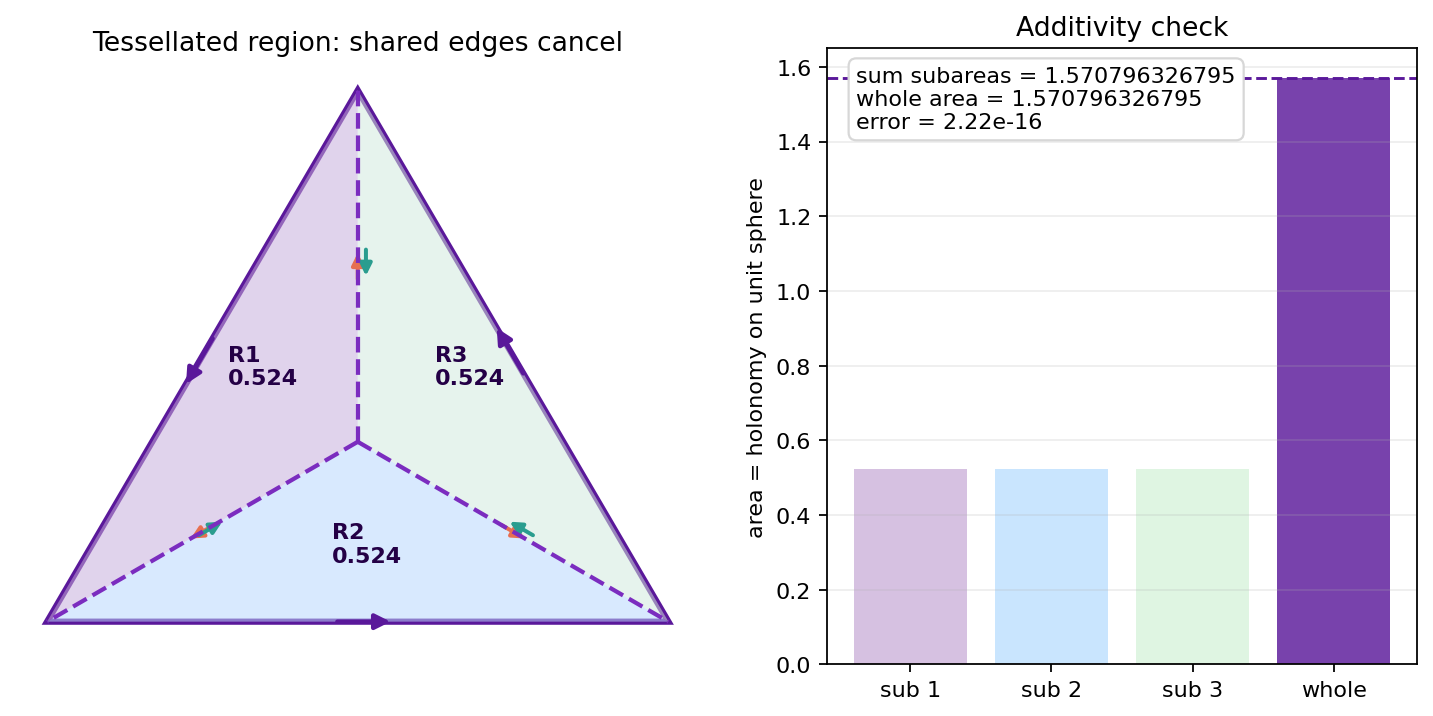

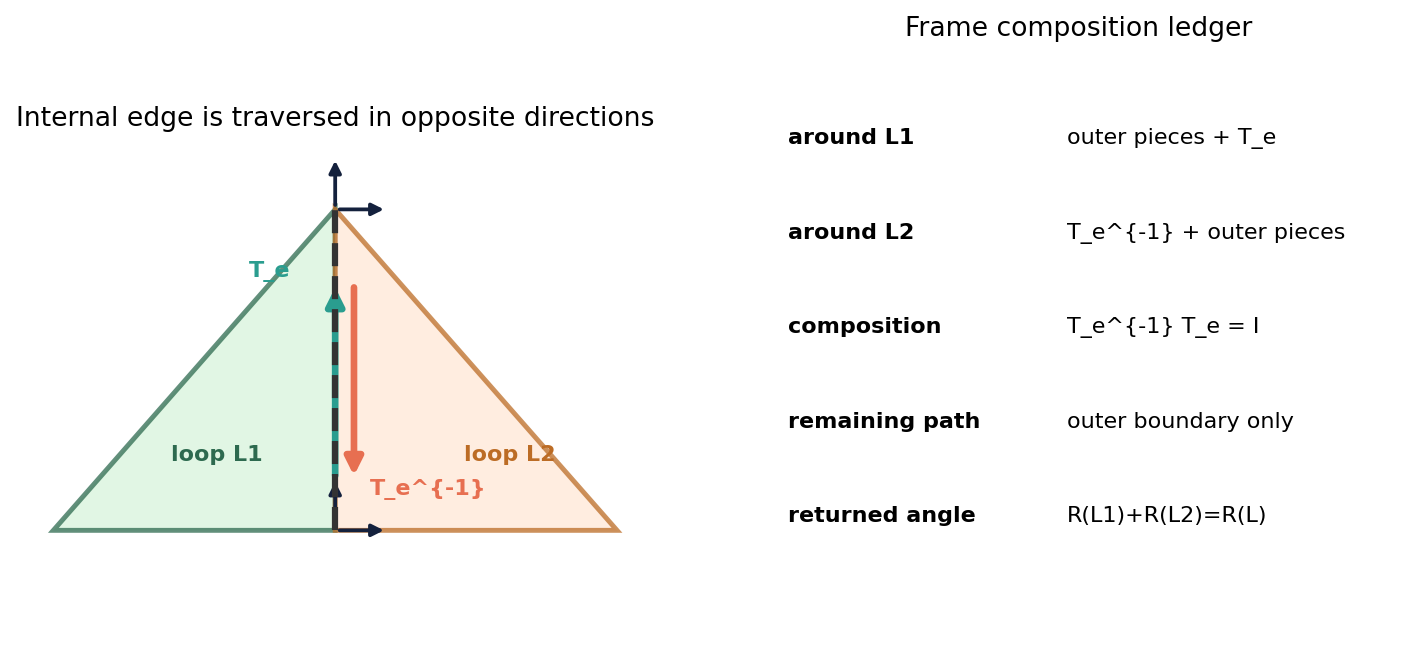

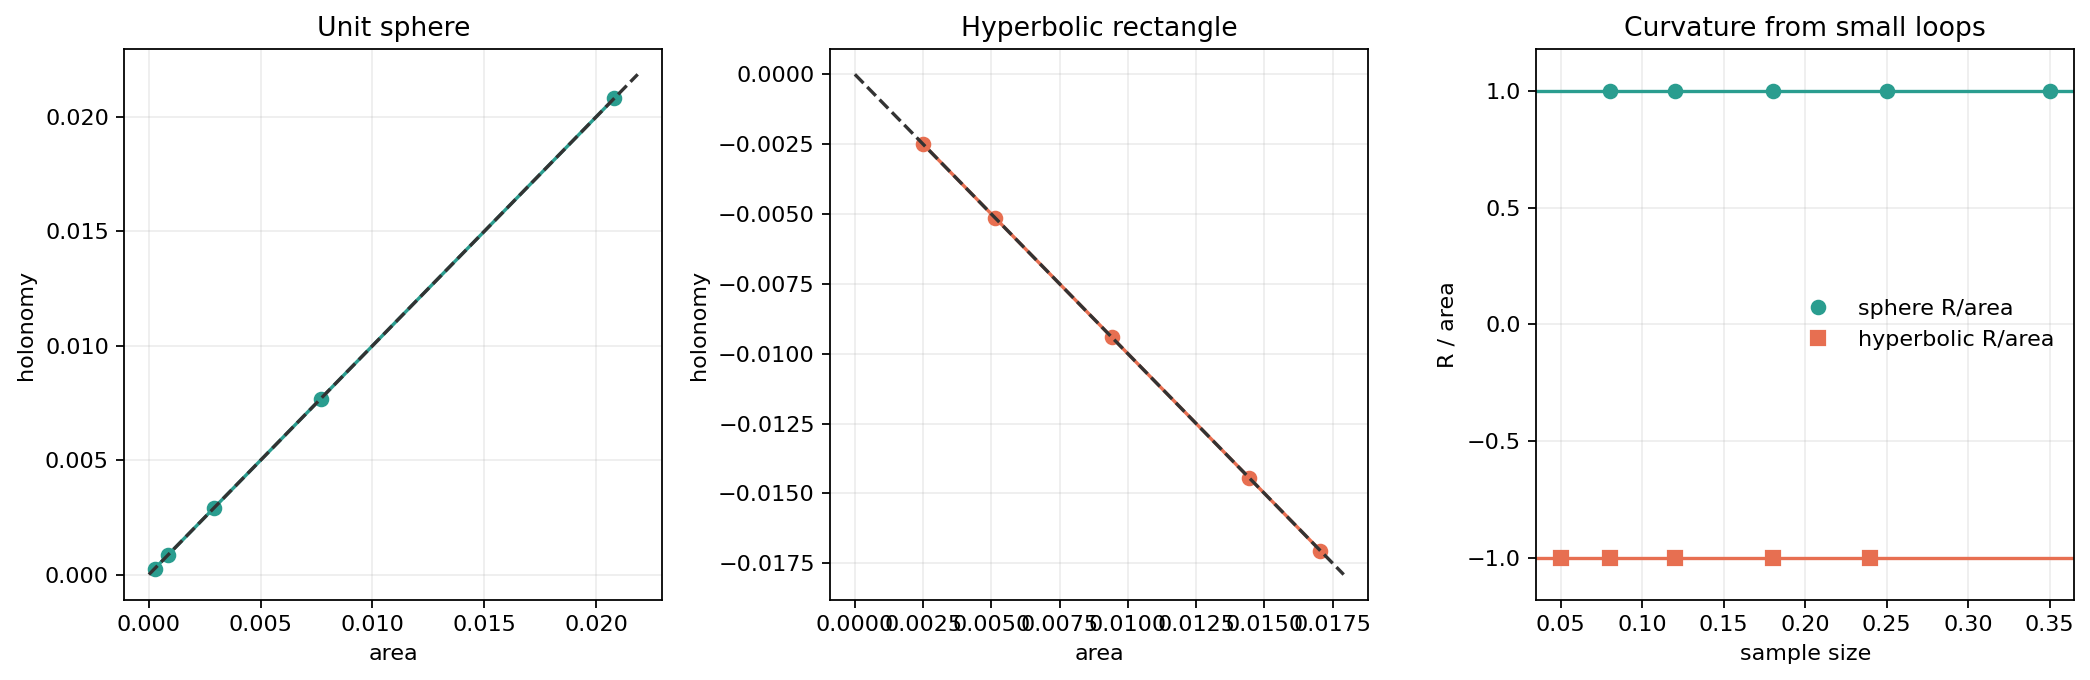

In [6]:
centroid = unit(north + equator_x + equator_y)
subtris = [(north, equator_x, centroid), (equator_x, equator_y, centroid), (equator_y, north, centroid)]
whole_area = spherical_triangle_area(north, equator_x, equator_y)
sub_areas = [spherical_triangle_area(*tri) for tri in subtris]
add_error = abs(whole_area - sum(sub_areas))

fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.3, 5.0), gridspec_kw={"width_ratios": [1.1, 0.95]})
P, Q, R = np.array([0.0, 2.2]), np.array([-1.9, -1.05]), np.array([1.9, -1.05])
M = np.array([0.0, 0.05])
ax.add_patch(Polygon(np.array([P, Q, R]), closed=True, facecolor="#f5f3ff", edgecolor="#5a189a", linewidth=2.8))
colors = ["#cdb4db", "#bde0fe", "#d8f3dc"]
for pts, color, label, subarea in zip([[P, Q, M], [Q, R, M], [R, P, M]], colors, ["R1", "R2", "R3"], sub_areas):
    ax.add_patch(Polygon(np.array(pts), closed=True, facecolor=color, edgecolor="none", alpha=0.5))
    c = np.mean(np.array(pts), axis=0)
    ax.text(c[0] - 0.16, c[1], f"{label}\n{subarea:.3f}", color="#240046", weight="bold")
for point in [P, Q, R]:
    ax.plot([M[0], point[0]], [M[1], point[1]], color="#7b2cbf", linewidth=1.9, linestyle="--")
    a, b = 0.55 * M + 0.45 * point, 0.45 * M + 0.55 * point
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=11, color="#e76f51", linewidth=1.8))
    ax.add_patch(FancyArrowPatch(b + np.array([0.05, 0.02]), a + np.array([0.05, 0.02]), arrowstyle="-|>", mutation_scale=11, color="#2a9d8f", linewidth=1.8))
for p0, p1 in [(P, Q), (Q, R), (R, P)]:
    ax.add_patch(FancyArrowPatch(0.54 * p0 + 0.46 * p1, 0.44 * p0 + 0.56 * p1, arrowstyle="-|>", mutation_scale=14, color="#5a189a", linewidth=2))
ax.set_title("Tessellated region: shared edges cancel")
ax.set_aspect("equal")
ax.axis("off")
labels = ["sub 1", "sub 2", "sub 3", "whole"]
values = sub_areas + [whole_area]
bx.bar(range(4), values, color=colors + ["#5a189a"], alpha=0.82)
bx.axhline(whole_area, color="#5a189a", linestyle="--", linewidth=1.3)
bx.set_xticks(range(4), labels)
bx.set_ylabel("area = holonomy on unit sphere")
bx.set_title("Additivity check")
bx.text(0.05, 0.87, f"sum subareas = {sum(sub_areas):.12f}\nwhole area = {whole_area:.12f}\nerror = {add_error:.2e}", transform=bx.transAxes, bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#d7d7d7"})
bx.grid(axis="y", alpha=0.22)
path = save_fig(fig, "holonomy-additivity-tessellation.png")
register(path, "Holonomy additivity over tessellated regions", "proof", "Matplotlib and NumPy", "Only uncanceled transport is on the outer boundary; the bar chart verifies additivity.", {"whole_area": whole_area, "sub_areas": sub_areas, "additivity_error": add_error})
computed_checks["additivity"] = {"whole_area": whole_area, "sub_areas": sub_areas, "additivity_error": add_error}
display_artifact(path, width=760)

fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.0, 4.8))
left, right = np.array([[-1.8, -0.9], [0, 1.15], [0, -0.9]]), np.array([[0, -0.9], [0, 1.15], [1.8, -0.9]])
ax.add_patch(Polygon(left, closed=True, facecolor="#d8f3dc", edgecolor="#2d6a4f", linewidth=2.2, alpha=0.75))
ax.add_patch(Polygon(right, closed=True, facecolor="#ffe8d6", edgecolor="#bc6c25", linewidth=2.2, alpha=0.75))
ax.plot([0, 0], [-0.9, 1.15], color="#333333", linewidth=2.8, linestyle="--")
ax.add_patch(FancyArrowPatch((0, -0.58), (0, 0.68), arrowstyle="-|>", mutation_scale=16, color="#2a9d8f", linewidth=3))
ax.add_patch(FancyArrowPatch((0.12, 0.68), (0.12, -0.58), arrowstyle="-|>", mutation_scale=16, color="#e76f51", linewidth=3))
ax.text(-0.55, 0.72, "T_e", color="#2a9d8f", weight="bold")
ax.text(0.22, -0.67, "T_e^{-1}", color="#e76f51", weight="bold")
for origin in [np.array([0.0, -0.9]), np.array([0.0, 1.15])]:
    ax.add_patch(FancyArrowPatch(origin, origin + np.array([0.34, 0.0]), arrowstyle="-|>", mutation_scale=11, color="#14213d", linewidth=1.7))
    ax.add_patch(FancyArrowPatch(origin, origin + np.array([0.0, 0.34]), arrowstyle="-|>", mutation_scale=11, color="#14213d", linewidth=1.7))
ax.text(-1.05, -0.45, "loop L1", color="#2d6a4f", weight="bold")
ax.text(0.82, -0.45, "loop L2", color="#bc6c25", weight="bold")
ax.set_title("Internal edge is traversed in opposite directions")
ax.set_aspect("equal")
ax.axis("off")
bx.axis("off")
bx.set_title("Frame composition ledger")
for y, (lhs, rhs) in zip([0.84, 0.68, 0.52, 0.36, 0.20], [("around L1", "outer pieces + T_e"), ("around L2", "T_e^{-1} + outer pieces"), ("composition", "T_e^{-1} T_e = I"), ("remaining path", "outer boundary only"), ("returned angle", "R(L1)+R(L2)=R(L)")]):
    bx.text(0.03, y, lhs, weight="bold", transform=bx.transAxes)
    bx.text(0.48, y, rhs, transform=bx.transAxes)
path = save_fig(fig, "transport-frame-cancellation.png")
register(path, "Transport frame cancellation", "proof", "Matplotlib", "Trace the two opposite arrows on the inserted edge and read the composition ledger.", {"inverse_transport_identity": True})
computed_checks["frame_cancellation"] = {"inverse_transport_identity": True}
display_artifact(path, width=760)

sphere_samples = []
for size in [0.08, 0.12, 0.18, 0.25, 0.35]:
    p = north
    q = np.array([math.sin(size), 0.0, math.cos(size)])
    r = np.array([math.sin(size) * math.cos(size), math.sin(size) * math.sin(size), math.cos(size)])
    v_start = tangent_toward_on_sphere(p, q)
    v_finish = sphere_loop_transport([p, q, r], v_start)
    hol = signed_tangent_angle(p, v_start, v_finish)
    ar = spherical_triangle_area(p, q, r)
    sphere_samples.append({"size": size, "area": ar, "holonomy": hol, "ratio": hol / ar})
hyperbolic_samples = []
for width, y1, height in [(0.05, 1.15, 0.07), (0.08, 1.20, 0.10), (0.12, 1.35, 0.16), (0.18, 1.55, 0.22), (0.24, 1.85, 0.28)]:
    y2 = y1 + height
    ar = width * (1 / y1 - 1 / y2)
    hol = -width / y1 + width / y2
    hyperbolic_samples.append({"width": width, "y1": y1, "y2": y2, "area": ar, "holonomy": hol, "ratio": hol / ar})
sphere_ratio_error = max(abs(s["ratio"] - 1.0) for s in sphere_samples)
hyperbolic_ratio_error = max(abs(s["ratio"] + 1.0) for s in hyperbolic_samples)
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.4))
sa, sh = np.array([s["area"] for s in sphere_samples]), np.array([s["holonomy"] for s in sphere_samples])
ha, hh = np.array([s["area"] for s in hyperbolic_samples]), np.array([s["holonomy"] for s in hyperbolic_samples])
axes[0].plot(sa, sh, "o-", color="#2a9d8f")
axes[0].plot([0, sa.max() * 1.05], [0, sa.max() * 1.05], color="#333333", linestyle="--")
axes[0].set_title("Unit sphere")
axes[0].set_xlabel("area")
axes[0].set_ylabel("holonomy")
axes[1].plot(ha, hh, "o-", color="#e76f51")
axes[1].plot([0, ha.max() * 1.05], [0, -ha.max() * 1.05], color="#333333", linestyle="--")
axes[1].set_title("Hyperbolic rectangle")
axes[1].set_xlabel("area")
axes[1].set_ylabel("holonomy")
axes[2].axhline(1, color="#2a9d8f")
axes[2].axhline(-1, color="#e76f51")
axes[2].plot([s["size"] for s in sphere_samples], [s["ratio"] for s in sphere_samples], "o", color="#2a9d8f", label="sphere R/area")
axes[2].plot([s["width"] for s in hyperbolic_samples], [s["ratio"] for s in hyperbolic_samples], "s", color="#e76f51", label="hyperbolic R/area")
axes[2].set_ylim(-1.18, 1.18)
axes[2].set_title("Curvature from small loops")
axes[2].set_xlabel("sample size")
axes[2].set_ylabel("R / area")
axes[2].legend(frameon=False)
for axis in axes:
    axis.grid(alpha=0.22)
fig.tight_layout()
path = save_fig(fig, "infinitesimal-curvature-rotation-check.png")
register(path, "Infinitesimal curvature-rotation checks", "numeric-check", "Matplotlib and NumPy", "Ratios sit at +1 for the unit sphere and -1 for the unit hyperbolic plane.", {"sphere_ratio_error": sphere_ratio_error, "hyperbolic_ratio_error": hyperbolic_ratio_error})
computed_checks["infinitesimal"] = {"sphere_samples": sphere_samples, "hyperbolic_samples": hyperbolic_samples, "sphere_ratio_error": sphere_ratio_error, "hyperbolic_ratio_error": hyperbolic_ratio_error}
display_artifact(path, width=820)

## Applied Lab And Final Sanity Checks

The parameter lab changes the longitude width `Theta` of a spherical wedge triangle. On the unit sphere the wedge area is `Theta`, and the returned angle is also `Theta`. This is a compact way to test whether the sign convention and transport rule are coherent before relying on a more complicated loop.

The last cell writes the refreshed storyboard, check JSON, and final sanity report. It asserts artifact existence, nonzero file size, nonblank PNG pixel variation, and the core symbolic and numerical identities.

In [7]:
lab_rows = []
for degrees in [15, 30, 45, 75, 90, 120]:
    width = math.radians(degrees)
    p = north
    q = np.array([1.0, 0.0, 0.0])
    r = np.array([math.cos(width), math.sin(width), 0.0])
    v_start = tangent_toward_on_sphere(p, q)
    v_finish = sphere_loop_transport([p, q, r], v_start)
    hol = signed_tangent_angle(p, v_start, v_finish)
    ar = spherical_triangle_area(p, q, r)
    lab_rows.append({"longitude_width_degrees": degrees, "area": ar, "holonomy": hol, "error": abs(hol - ar)})
lab_path = save_json({"description": "Spherical wedge lab: holonomy equals longitude width and area on the unit sphere.", "rows": lab_rows}, ARTIFACT_TOPIC, CHECK_SLUG, "holonomy-parameter-lab.json", root=ARTIFACT_BASE)
computed_checks["parameter_lab"] = {"rows": lab_rows, "max_error": max(row["error"] for row in lab_rows), "json": rel_path(lab_path)}

artifact_filenames = [item["filename"] for item in visual_registry]
storyboard_filenames = [item["filename"] for item in storyboard["visual_sequence"]]
assertions = {
    "source_span_recorded": source_span["printed_pages"] == "245-251" and source_span["pdf_pages"] == "274-280",
    "storyboard_matches_generated_visuals": sorted(artifact_filenames) == sorted(storyboard_filenames),
    "has_visual_sequence": len(visual_registry) >= 8,
    "all_visuals_exist": all((BOOK_ROOT / item["relative_path"]).exists() for item in visual_registry),
    "all_visuals_nonblank": all(item["metrics"].get("nonblank", False) for item in visual_registry),
    "all_visuals_concept_named": all(name not in {"figure.png", "plot.png", "image.png", "data.png"} for name in artifact_filenames),
    "sphere_holonomy_equals_excess": computed_checks["sphere_octant"]["absolute_error"] < 1e-12,
    "sphere_area_equals_excess": abs(computed_checks["sphere_octant"]["area"] - computed_checks["sphere_octant"]["spherical_excess"]) < 1e-12,
    "triangle_ledger_symbolic_identity": computed_checks["triangle_ledger"]["sympy_residual"] == "0",
    "hyperbolic_triangle_negative_holonomy": computed_checks["hyperbolic_triangle"]["holonomy"] < 0,
    "hyperbolic_triangle_holonomy_is_minus_area": computed_checks["hyperbolic_triangle"]["holonomy_plus_area_error"] < 1e-12,
    "additivity_solid_angle_residual_small": computed_checks["additivity"]["additivity_error"] < 1e-12,
    "frame_inverse_identity_recorded": computed_checks["frame_cancellation"]["inverse_transport_identity"] is True,
    "infinitesimal_sphere_ratio_is_positive_one": computed_checks["infinitesimal"]["sphere_ratio_error"] < 1e-10,
    "infinitesimal_hyperbolic_ratio_is_negative_one": computed_checks["infinitesimal"]["hyperbolic_ratio_error"] < 1e-12,
    "parameter_lab_holonomy_matches_area": computed_checks["parameter_lab"]["max_error"] < 1e-12,
}
check_payload = {
    "chapter_label": source_span["label"],
    "title": source_span["title"],
    "chapter_goal": storyboard["chapter_goal"],
    "source_span": source_span,
    "storyboard": rel_path(storyboard_path),
    "visual_artifacts": visual_registry,
    "artifact_filenames": artifact_filenames,
    "computations": computed_checks,
    "assertions": assertions,
}
check_path = save_json(check_payload, ARTIFACT_TOPIC, CHECK_SLUG, "holonomy-equals-curvature.json", root=ARTIFACT_BASE)
final_sanity = {
    "chapter_label": source_span["label"],
    "title": source_span["title"],
    "source_span": {"printed_pages": source_span["printed_pages"], "pdf_pages": source_span["pdf_pages"]},
    "storyboard": rel_path(storyboard_path),
    "check_artifact": rel_path(check_path),
    "parameter_lab": computed_checks["parameter_lab"]["json"],
    "visual_artifacts": [item["relative_path"] for item in visual_registry],
    "visual_count": len(visual_registry),
    "assertions": assertions,
}
final_path = save_json(final_sanity, ARTIFACT_TOPIC, CHECK_SLUG, "final-sanity.json", root=ARTIFACT_BASE)

failed = [name for name, passed in assertions.items() if not passed]
assert not failed, failed
for item in visual_registry:
    path = BOOK_ROOT / item["relative_path"]
    assert path.exists(), item["relative_path"]
    assert path.stat().st_size > 1000, item["relative_path"]
    if item["metrics"]["suffix"] == ".png":
        assert item["metrics"]["pixel_std"] > 1.0, item["relative_path"]

print("width(deg)      area(rad)   holonomy(rad)      error")
for row in lab_rows:
    print(f"{row['longitude_width_degrees']:>9.0f}   {row['area']:>12.9f}   {row['holonomy']:>13.9f}   {row['error']:.2e}")
print(rel_path(check_path))
print(rel_path(final_path))
print(json.dumps(assertions, indent=2, sort_keys=True))

width(deg)      area(rad)   holonomy(rad)      error
       15    0.261799388     0.261799388   0.00e+00
       30    0.523598776     0.523598776   0.00e+00
       45    0.785398163     0.785398163   1.11e-16
       75    1.308996939     1.308996939   0.00e+00
       90    1.570796327     1.570796327   0.00e+00
      120    2.094395102     2.094395102   0.00e+00
artifacts/chapter-24/checks/holonomy-equals-curvature.json
artifacts/chapter-24/checks/final-sanity.json
{
  "additivity_solid_angle_residual_small": true,
  "all_visuals_concept_named": true,
  "all_visuals_exist": true,
  "all_visuals_nonblank": true,
  "frame_inverse_identity_recorded": true,
  "has_visual_sequence": true,
  "hyperbolic_triangle_holonomy_is_minus_area": true,
  "hyperbolic_triangle_negative_holonomy": true,
  "infinitesimal_hyperbolic_ratio_is_negative_one": true,
  "infinitesimal_sphere_ratio_is_positive_one": true,
  "parameter_lab_holonomy_matches_area": true,
  "source_span_recorded": true,
  "sphere_are